# 03. Predictive Modeling, Time-Aware Validation & Explainability

This notebook establishes an econometric and machine learning benchmarking pipeline for residential apartment valuation in Poznań. It implements time-series-aware cross-validation, out-of-time expanding window backtesting, residual diagnostics, and multi-model explainability.

---

### Modeling Framework & Validation Protocol
1. **Algorithmic Suite:**
   - **Linear Baselines:** Ridge Regression & ElasticNet (L1/L2 regularization).
   - **Tree Ensembles:** Random Forest, LightGBM, CatBoost, and tuned XGBoost.
   - **Deep Learning:** PyTorch Residual Multi-Layer Perceptron (MLP) with Huber loss and AdamW.
2. **Time-Aware Validation:**
   - Strict chronological ordering (`rok_miesiac_float`) with `TimeSeriesSplit` to eliminate temporal lookahead leakage.
   - Out-of-time expanding-window evaluation across 2014–2025, mirroring real-world deployment where models train on historical data and predict future transactions.
3. **Macroeconomic Shock Analysis:**
   - Overlaying yearly predictive accuracy ($R^2$, $\text{MAE}$) against the WIBOR 3M interest rate shock (2021–2023), illustrating how macroeconomic regime shifts degrade spatial-physical hedonic relationships.
4. **Explainability & Attribution:**
   - **TreeSHAP:** Global and local feature attributions for tuned XGBoost.
   - **KernelSHAP:** Model-agnostic attribution for the PyTorch MLP.
   - **Glass-Box Decision Tree:** A shallow decision tree ($d=3$) trained on raw PLN/$\text{m}^2$ for human-interpretable valuation heuristics.


## 1. Environment & Cross-Validation Benchmark Suite
Initialize models and evaluate baseline algorithms using 5-fold `TimeSeriesSplit` with leak-free fold preprocessing.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling import evaluate_models_cv, tune_and_compare, time_split

root = project_root
df = pd.read_csv(root / "data" / "processed" / "housing_residential_market.csv")
df = df.sort_values("rok_miesiac_float").reset_index(drop=True)
feature_cols = [
    "powierzchnia_final", "liczba_izb", "metry_na_izbe", "nr_kondygnacji",
    "odl_do_centrum", "wsp_x", "wsp_y",
    "rok_miesiac_float", "wibor_3m", "srednie_wynagrodzenie",
    "osiedle_cat", "is_pierwotny", "sprzedajacy_firma",
    "ma_pomieszczenia_przynalezne",
]
X = df[[c for c in feature_cols if c in df.columns]].copy()
y = np.log1p(df["cena_za_m2"])
X["osiedle_cat"] = X["osiedle_cat"].astype(str)
X.head()

/home/gienon/source/repos/ml/projekt/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,powierzchnia_final,liczba_izb,metry_na_izbe,nr_kondygnacji,odl_do_centrum,wsp_x,wsp_y,rok_miesiac_float,wibor_3m,srednie_wynagrodzenie,osiedle_cat,is_pierwotny,sprzedajacy_firma,ma_pomieszczenia_przynalezne
0,89.0,5.0,17.8,1.0,2.309598,5810882.929,6427285.956,2011.0,3.95,3311.0,27,0,1,0
1,37.5,3.0,12.5,9.0,3.022040,5806643.657,6424948.430,2011.0,3.95,3311.0,38,0,1,1
2,48.0,4.0,12.0,4.0,3.671792,5806837.372,6424038.658,2011.0,3.95,3311.0,38,0,1,1
3,31.6,2.0,15.8,4.0,2.342581,5807817.792,6429491.534,2011.0,3.95,3311.0,24,0,1,1
4,65.2,4.0,16.3,7.0,5.233702,5803680.464,6425416.411,2011.0,3.95,3311.0,36,0,1,1


In [2]:
comparison = evaluate_models_cv(X, y, cv_folds=5)
comparison

,Model,Mean_CV_R2,Std_CV_R2,Mean_MAE_PLN,Mean_RMSE_PLN,Mean_MAPE,Fold_R2_Scores
2,XGBoost,0.3493,0.0169,1460.0,1914.0,14.46,"[0.3557580341471942, 0.332712879166161, 0.3456..."
1,Random Forest,0.2796,0.0229,1567.0,2035.0,15.36,"[0.30397397966741124, 0.25506565669333114, 0.2..."
0,ElasticNet,0.1780,0.0698,1677.0,2158.0,16.92,"[0.06049493759341551, 0.24426833706076267, 0.1..."


## 2. Bayesian Hyperparameter Tuning & Cross-Validation Comparison
Perform hyperparameter tuning for XGBoost, CatBoost, LightGBM, and Random Forest using temporal cross-validation with an evaluation gap.


In [3]:
best_model, best_params, comparison_df = tune_and_compare(X, y, n_iter=10, n_splits=5, test_size=2000, gap=200)
best_params

Tuning XGBoost (TimeSeriesSplit, n_iter=10)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
  Done in 10s — Best R² (log): 0.3648
  Best params: {'model__subsample': 1.0, 'model__reg_lambda': 5.0, 'model__n_estimators': 700, 'model__min_child_weight': 3, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.85}
Evaluating MLP + DecisionTree (TimeSeriesSplit)...
  Done in 37s

Final comparison (interpretable metrics):
                     Model  Mean_CV_R2  Std_CV_R2  Mean_MAE_PLN  Mean_RMSE_PLN  Mean_MAPE
           XGBoost (Tuned)      0.3648     0.0291        1446.0         1892.0      14.32
        MLP (scikit-learn)     -0.1756     0.3432        1893.0         2437.0      19.33
DecisionTree (max_depth=3)      0.0833     0.0732        1835.0         2335.0      17.44


{'model__subsample': 1.0,
 'model__reg_lambda': 5.0,
 'model__n_estimators': 700,
 'model__min_child_weight': 3,
 'model__max_depth': 4,
 'model__learning_rate': 0.1,
 'model__colsample_bytree': 0.85}

## 3. Deep Learning Baseline: PyTorch Residual MLP
Train a custom PyTorch Multi-Layer Perceptron with residual connections, layer normalization, dropout, and Huber loss, evaluating across expanding annual windows.


In [4]:
from src.mlp import evaluate_mlp_temporal

mlp_results = evaluate_mlp_temporal(
    X=X,
    y=y,
    years=df["rok"],
    hidden=128,
    n_blocks=3,
    dropout=0.2,
    max_epochs=80,
    patience=12,
    batch_size=256,
    plot_folds=False,
)
mlp_results.head()

  2014: R²=0.176  MAE=1,319 PLN/m²  (train=4,845)
  2015: R²=0.182  MAE=1,272 PLN/m²  (train=6,699)
  2016: R²=0.290  MAE=1,185 PLN/m²  (train=8,774)
  2017: R²=0.268  MAE=1,268 PLN/m²  (train=11,033)
  2018: R²=0.236  MAE=1,386 PLN/m²  (train=13,518)
  2019: R²=0.229  MAE=1,478 PLN/m²  (train=16,186)
  2020: R²=0.279  MAE=1,456 PLN/m²  (train=19,153)
  2021: R²=0.249  MAE=1,477 PLN/m²  (train=21,776)
  2022: R²=0.075  MAE=1,702 PLN/m²  (train=25,339)
  2023: R²=0.226  MAE=1,622 PLN/m²  (train=28,415)
  2024: R²=0.231  MAE=1,656 PLN/m²  (train=31,523)
  2025: R²=0.094  MAE=1,684 PLN/m²  (train=34,675)
── MLP expanding-window summary ─────────────────────────
  Mean R²  : 0.211  ±0.068
  Mean MAE : 1,459 PLN/m²


,year,n_train,n_val,r2,mae_pln,rmse_pln,mape
0,2014,4845,1854,0.176238,1318.851754,1790.246664,15.901142
1,2015,6699,2075,0.182383,1272.378654,1764.723694,15.773559
2,2016,8774,2259,0.290188,1185.177969,1628.273833,14.403723
3,2017,11033,2485,0.268285,1268.261951,1701.186075,15.212637
4,2018,13518,2668,0.235834,1386.155286,1857.957197,14.810736


## 4. Chronological Train-Test Holdout Evaluation
Split the dataset chronologically (80% train / 20% test) based on transaction execution date (`data_dokumentu`) to test generalizability.


In [5]:
train_df, test_df = time_split(df, date_col="data_dokumentu")
print(f"train rows: {len(train_df):,}")
print(f"test rows: {len(test_df):,}")

train rows: 30,523
test rows: 7,631


## 5. Out-of-Time Expanding Window Backtesting (2014–2025)
Evaluate model stability over time by training on all historical data prior to year $t$ and testing exclusively on year $t$, computing real-space metrics ($\text{PLN/m}^2$) via $\exp(y) - 1$.


In [6]:
from src.modeling import evaluate_yearly_model_performance

yearly_df = evaluate_yearly_model_performance(
    X=X,
    y=y,
    years=df["rok"],
    model_params={k.replace("model__", ""): v for k, v in best_params.items()},
)
yearly_df.head()


,year,train_rows,test_rows,r2,mae_pln,mape,median_actual_price
0,2013,3163,1682,0.413856,1043.380976,13.983517,7710.299873
1,2014,4845,1854,0.371205,1084.615426,13.760274,7928.315865
2,2015,6699,2075,0.348426,1093.757609,13.787857,7969.002095
3,2016,8774,2259,0.414483,1080.451146,13.292211,8273.376678
4,2017,11033,2485,0.399262,1092.905039,13.319503,8546.706940


## 6. Local Market Benchmark & Temporal Autocorrelation
Assess temporal autocorrelation and establish a baseline comparison against median district-level pricing.


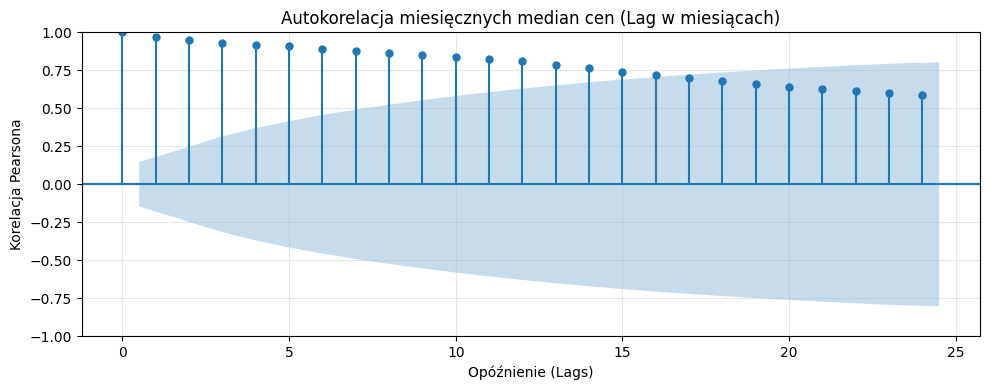

In [7]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plots_dir = project_root / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

monthly_median = df.groupby('rok_miesiac_float')['cena_za_m2'].median().dropna()
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(monthly_median, lags=24, ax=ax, title='Autokorelacja miesięcznych median cen (Lag w miesiącach)')
ax.set_xlabel('Opóźnienie (Lags)')
ax.set_ylabel('Korelacja Pearsona')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(plots_dir / 'acf.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Cross-Validation Stability Across Folds
Boxplots of fold-level $R^2$ scores quantify model variance and stability across temporal folds.


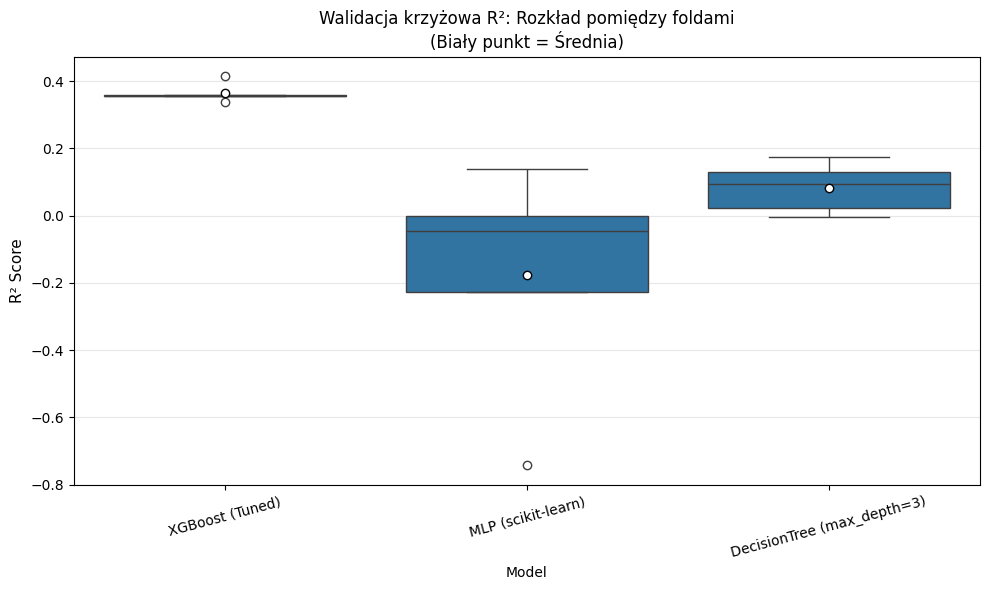

In [8]:
from src.viz import plot_model_comparison_cv

plots_dir = project_root / 'plots'
plots_dir.mkdir(parents=True, exist_ok=True)

plot_model_comparison_cv(comparison_df, save_path=str(plots_dir / 'cv_model_comparison.png'))

## 8. Macroeconomic Shock Diagnostics: The 2022 Interest Rate Shift
The dual-axis analysis overlays annual out-of-time $R^2$ and MAE against the WIBOR 3M benchmark.
The rapid monetary tightening in 2022 caused an immediate degradation in predictive performance ($R^2$ dropping from $0.266$ to $0.105$), demonstrating that spatial-physical hedonic relationships weaken during systemic macroeconomic regime changes.


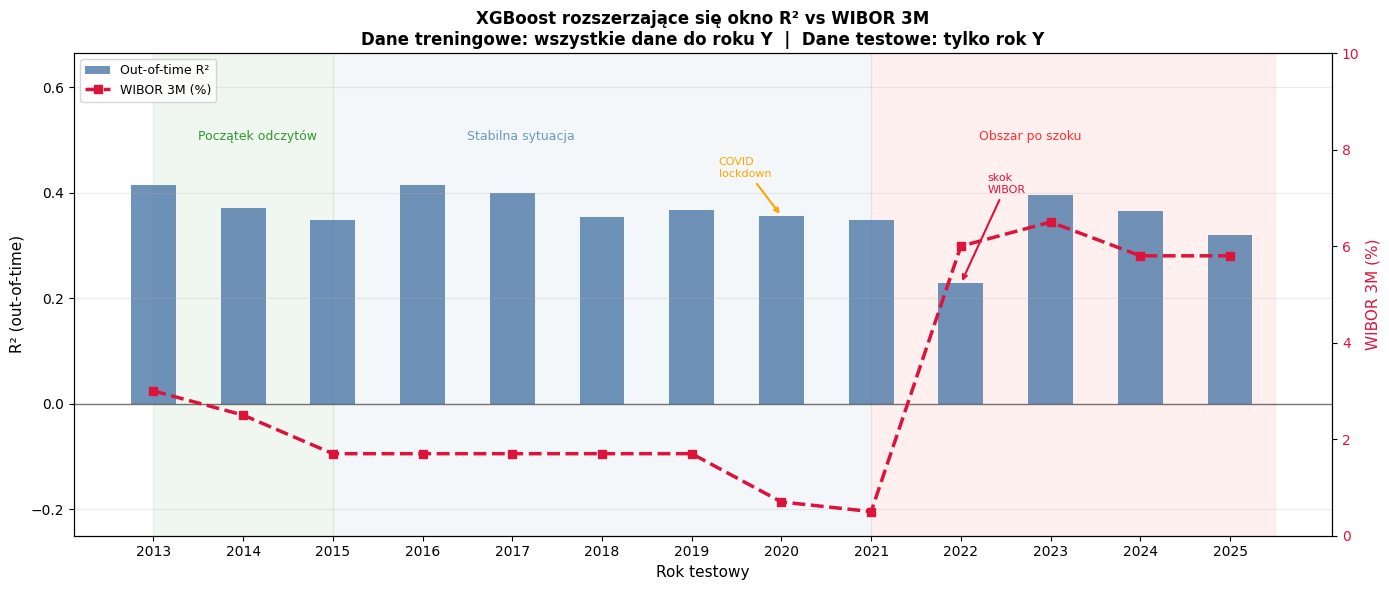

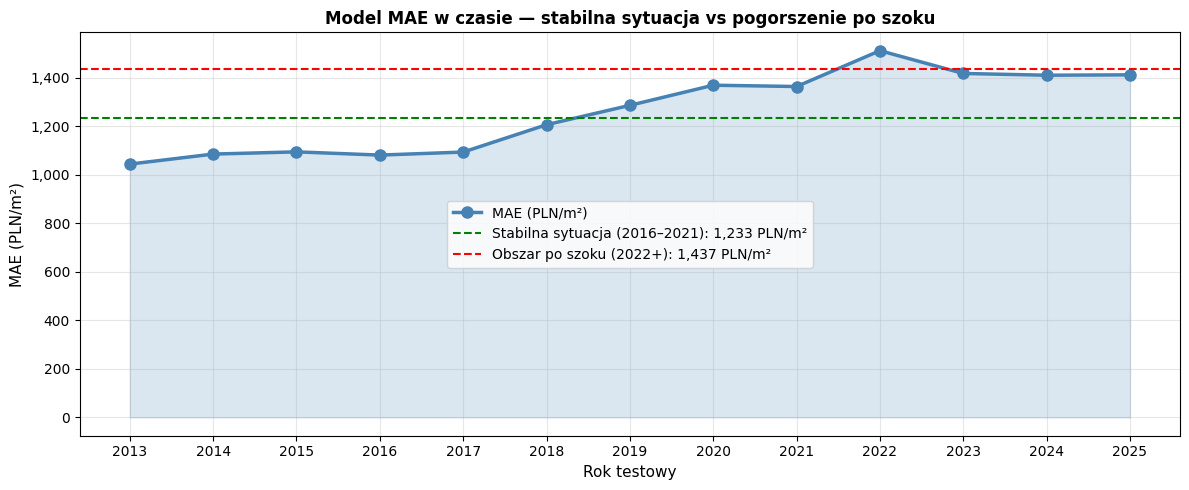

MAE Shock Impact: 16.6% error increase post-2021.
Stable-era MAE: 1,233 PLN/m²
Post-shock MAE: 1,437 PLN/m²


In [9]:
from src.viz import plot_yearly_performance_vs_wibor, plot_mae_trend

plot_yearly_performance_vs_wibor(yearly_df, save_path=str(plots_dir / 'yearly_performance_vs_wibor.png'))

mae_metrics = plot_mae_trend(
    yearly_df,
    stable_years=(2016, 2021),
    shock_year_start=2022,
    save_path=str(plots_dir / 'mae_trend.png'),
)
print(f"MAE Shock Impact: {mae_metrics['delta_pct']:.1f}% error increase post-2021.")
print(f"Stable-era MAE: {mae_metrics['stable_mae']:,.0f} PLN/m²")
print(f"Post-shock MAE: {mae_metrics['shock_mae']:,.0f} PLN/m²")

## 9. Residual Diagnostics: Error Normality & Homoscedasticity
Standard heteroscedasticity and distribution checks confirm error normality and absence of pathological bias.


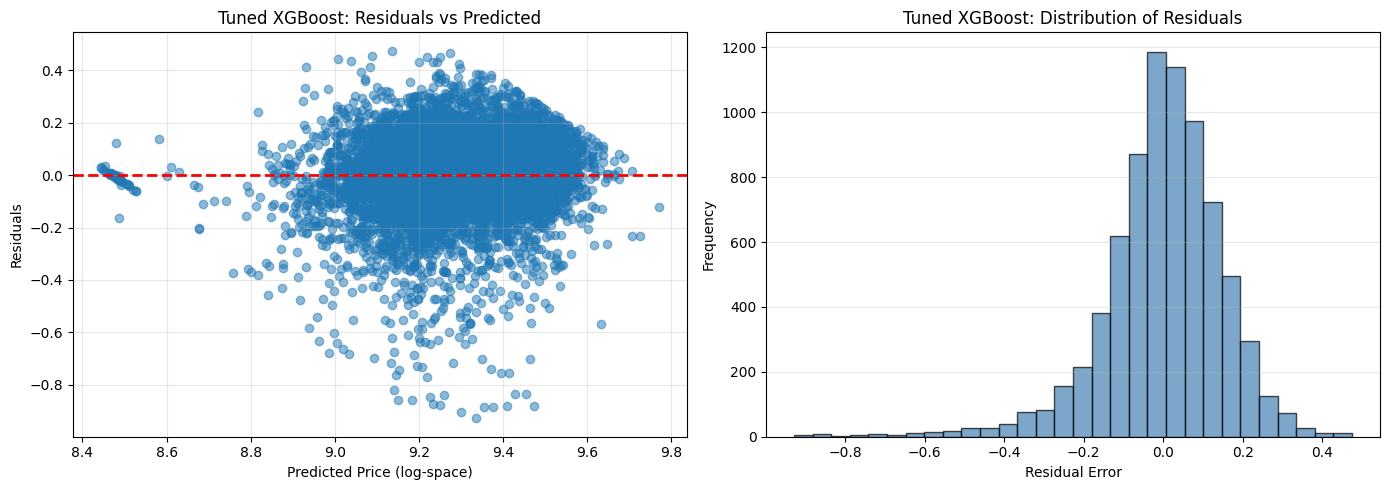

In [10]:
from src.viz import plot_residuals

train_df, test_df = time_split(df, date_col='data_dokumentu', test_size=0.2)
X_test = test_df[[c for c in feature_cols if c in test_df.columns]].copy()
X_test['osiedle_cat'] = X_test['osiedle_cat'].astype(str)
y_test_log = np.log1p(test_df['cena_za_m2'])

preds_log = best_model.predict(X_test)
plot_residuals(y_test_log.values, preds_log, model_name='Tuned XGBoost')

## 10. Global & Local Interpretability (TreeSHAP)
TreeSHAP attribution quantifies the impact of each feature on predicted $\log(\text{cena\_za\_m}^2)$.
Apartment layout (`powierzchnia_final`), spatial proximity (`odl_do_centrum`), and macroeconomic timing (`rok_miesiac_float`, `wibor_3m`) dominate valuation.


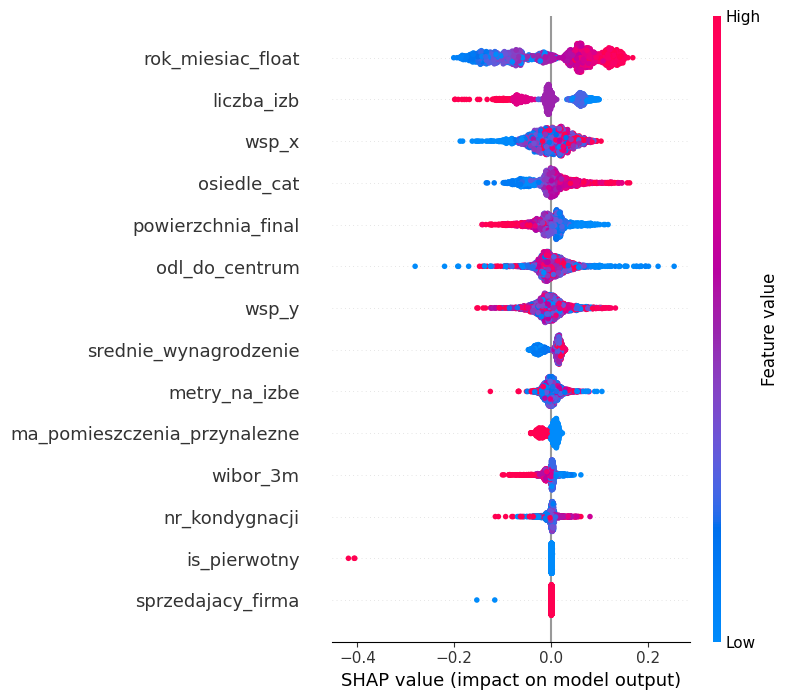

,Feature,Mean_SHAP
0,rok_miesiac_float,0.088709
1,liczba_izb,0.043046
2,wsp_x,0.030375
3,osiedle_cat,0.028751
4,powierzchnia_final,0.025887
5,odl_do_centrum,0.025049
6,wsp_y,0.024434
7,srednie_wynagrodzenie,0.019459
8,metry_na_izbe,0.012421
9,ma_pomieszczenia_przynalezne,0.011860


In [11]:
from src.modeling import generate_shap_explanations

explainer, shap_values, importance_df = generate_shap_explanations(
    best_model, X, sample_n=2000, save_path=str(plots_dir / 'xgb_shap.png')
)
importance_df.head(10)

## 11. Neural Network Attribution (KernelSHAP vs. TreeSHAP)
KernelSHAP provides model-agnostic feature attributions for the PyTorch MLP, enabling direct comparison of feature hierarchies between gradient boosting and deep learning.


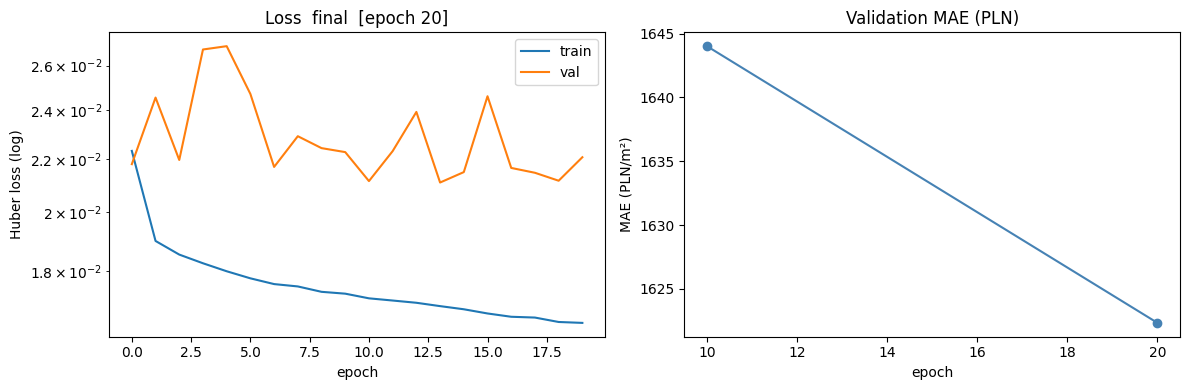

Obliczanie wartości SHAP dla MLP (tło: 100, próbka: 500)...
Uwaga: Dla sieci neuronowej może to potrwać od kilkunastu do kilkudziesięciu sekund.


100%|██████████| 500/500 [00:12<00:00, 41.16it/s]


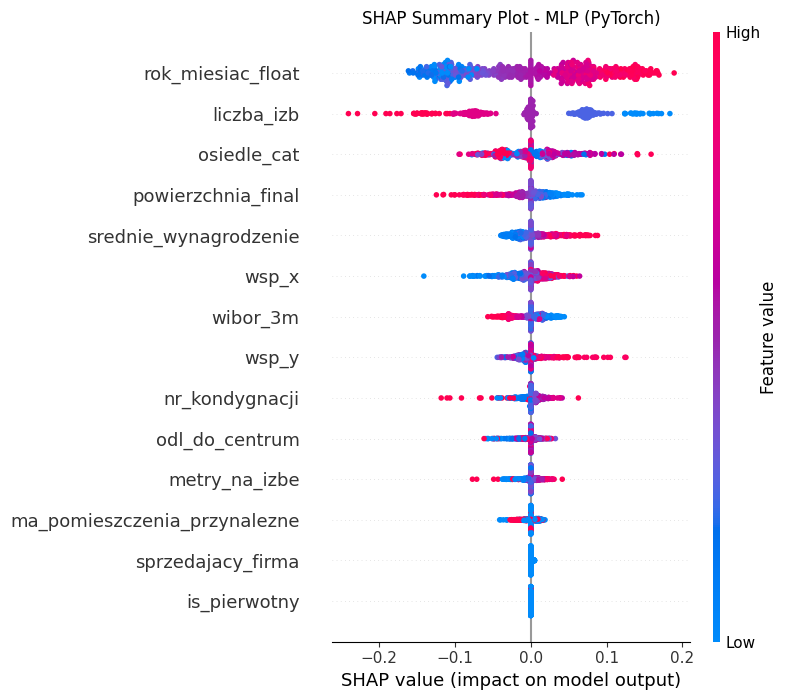

,Feature,Mean_SHAP
0,rok_miesiac_float,0.079152
1,liczba_izb,0.057278
2,osiedle_cat,0.031031
3,powierzchnia_final,0.020787
4,srednie_wynagrodzenie,0.019416
5,wsp_x,0.018336
6,wibor_3m,0.016721
7,wsp_y,0.013792
8,nr_kondygnacji,0.009631
9,odl_do_centrum,0.007455


In [12]:
from src.mlp import train_final_mlp
from src.modeling import generate_mlp_shap

mlp_model, mlp_scaler, mlp_encoder = train_final_mlp(
    X, y, val_frac=0.1,
    hidden=128, n_blocks=3, dropout=0.2,
    max_epochs=80, patience=12, batch_size=256,
)

mlp_explainer, mlp_shap_values, mlp_importance = generate_mlp_shap(
    mlp_model, mlp_scaler, mlp_encoder, X,
    sample_n=500, bg_n=100,
    save_path=str(plots_dir / 'shap_mlp.png'),
)
mlp_importance.head(10)

## 12. Interpretable Glass-Box Benchmark (Shallow Decision Tree)
A shallow decision tree ($d=3$) trained on raw PLN/$\text{m}^2$ prices provides a human-readable set of valuation heuristics, serving as a transparent baseline for institutional appraisal.


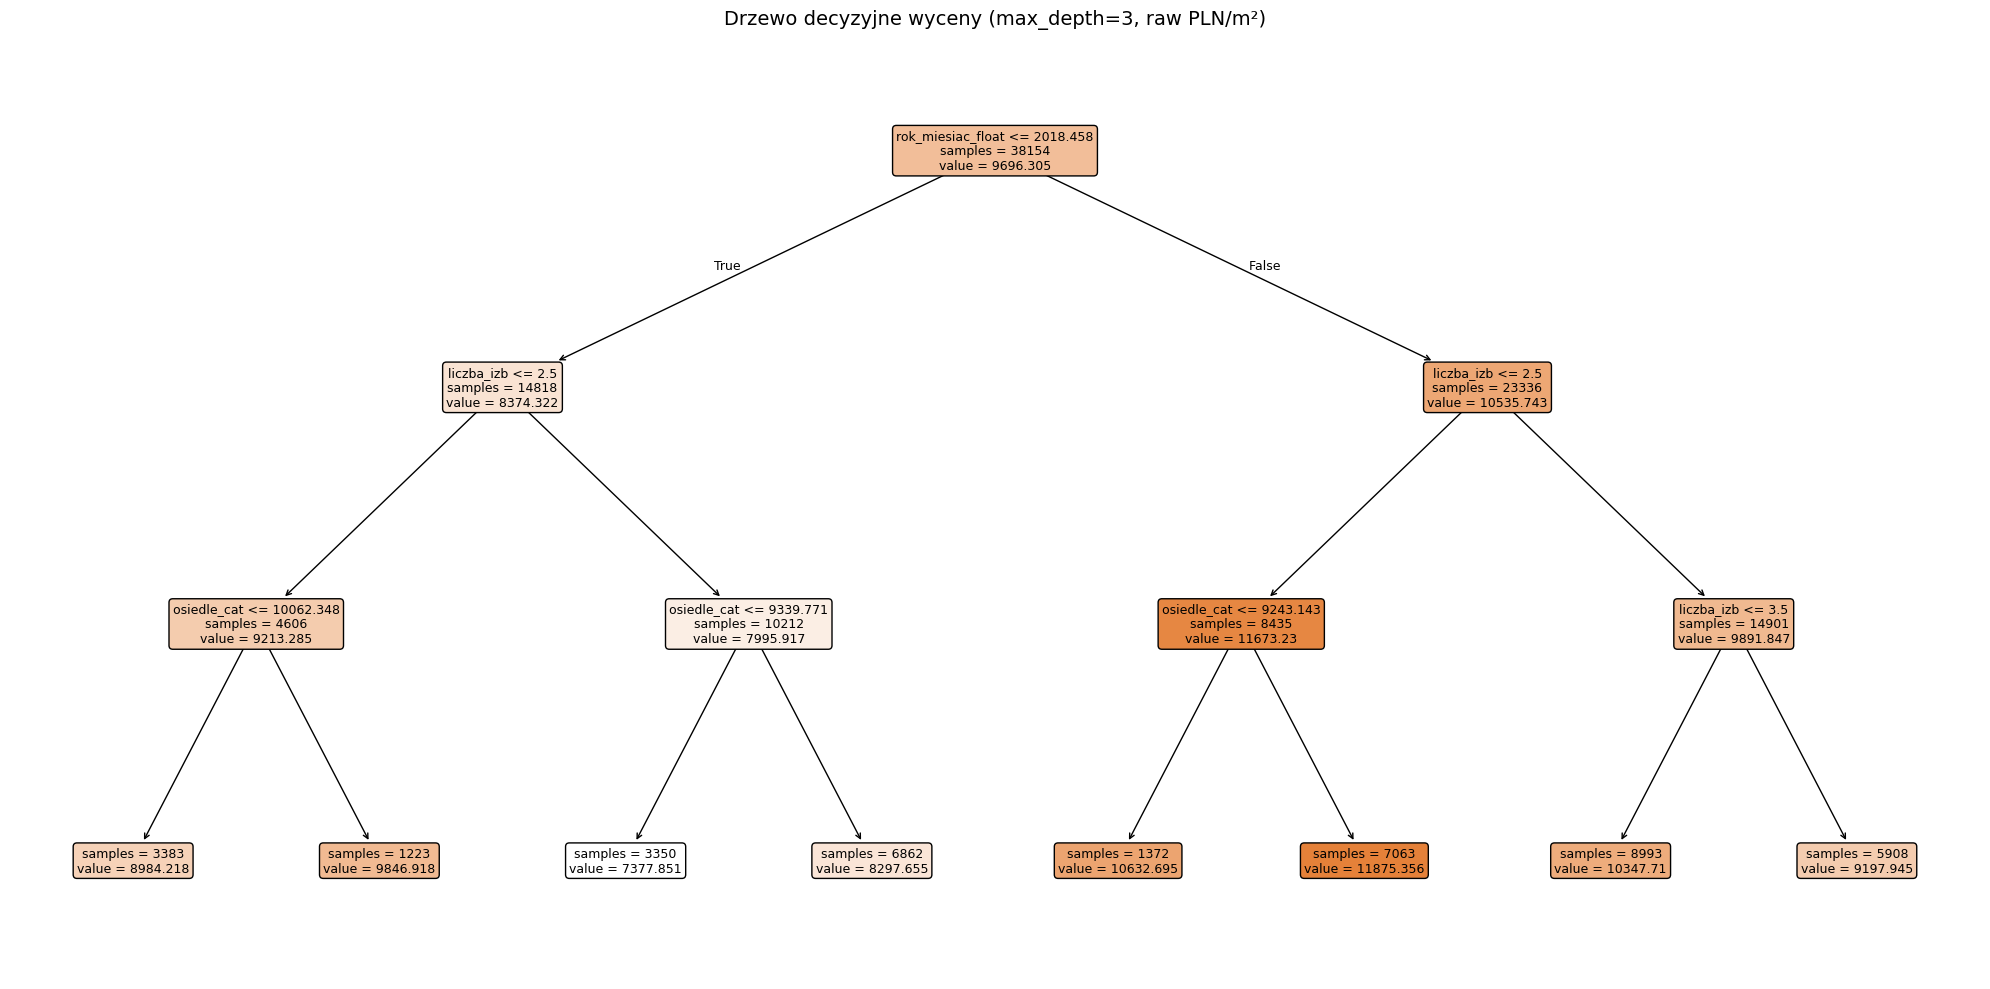

|--- rok_miesiac_float <= 2018
|   |--- liczba_izb <= 2
|   |   |--- osiedle_cat <= 10062
|   |   |   |--- value: [8984]
|   |   |--- osiedle_cat >  10062
|   |   |   |--- value: [9847]
|   |--- liczba_izb >  2
|   |   |--- osiedle_cat <= 9340
|   |   |   |--- value: [7378]
|   |   |--- osiedle_cat >  9340
|   |   |   |--- value: [8298]
|--- rok_miesiac_float >  2018
|   |--- liczba_izb <= 2
|   |   |--- osiedle_cat <= 9243
|   |   |   |--- value: [10633]
|   |   |--- osiedle_cat >  9243
|   |   |   |--- value: [11875]
|   |--- liczba_izb >  2
|   |   |--- liczba_izb <= 4
|   |   |   |--- value: [10348]
|   |   |--- liczba_izb >  4
|   |   |   |--- value: [9198]



In [13]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.impute import SimpleImputer
from category_encoders.target_encoder import TargetEncoder

# Train on raw PLN/m² for intuitive splits
y_raw = df['cena_za_m2']
X_tree = X.copy()

te = TargetEncoder(cols=['osiedle_cat'], handle_missing='value')
X_tree = te.fit_transform(X_tree, y_raw)
X_tree = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(X_tree),
    columns=X_tree.columns, index=X_tree.index,
)

tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_tree, y_raw)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(tree, feature_names=list(X_tree.columns), filled=True,
          rounded=True, fontsize=9, ax=ax, impurity=False)
ax.set_title('Drzewo decyzyjne wyceny (max_depth=3, raw PLN/m²)', fontsize=14)
fig.tight_layout()
fig.savefig(plots_dir / 'decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

print(export_text(tree, feature_names=list(X_tree.columns), decimals=0))